# Exp6 — Eval All Router Sizes (Colab A100)

Runs FP16 inference on 373 clean val samples for 5 merged router models.

**Metrics** (aligned with v4 notebook evaluation methodology):
- **Routing accuracy** = intent + scope both correct (primary metric, same as v4)
- Intent accuracy + Wilson 95% CI
- Scope accuracy
- Macro-F1 + per-intent F1
- Per-intent accuracy + top confusion pairs (same as v4)
- Rewrite routing accuracy + entity coverage (multi-turn samples)
- Latency P50/P90/P95 (GPU FP16, not production Ollama CPU)

**Output**: `exp6_summary.json` + plots + per-sample CSV.

⚠️ **Quantization note**: This notebook uses **FP16** (merged_16bit on HF). Production deployment
uses **Q4_K_M GGUF** via Ollama — expected delta ≤1pp, negligible for ranking.


In [1]:
%%capture
!pip install -U transformers accelerate huggingface_hub scikit-learn


In [2]:
import os, json, time, re, gc, math
import torch
from pathlib import Path
from collections import Counter, defaultdict
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

HF_TOKEN = userdata.get('HF_TOKEN')
assert HF_TOKEN, 'Set HF_TOKEN in Colab Secrets'
login(token=HF_TOKEN)

import subprocess
gpu = subprocess.check_output(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader']).decode().strip()
print(f'GPU: {gpu}')


GPU: NVIDIA A100-SXM4-80GB, 81920 MiB


In [3]:
# ═══════════════════════ CONFIGS ═══════════════════════
HF_DATA_REPO = 'daredevil467/hanoi-weather-router-data'

MODELS = [
    ('Qwen2.5-0.5B', 'daredevil467/hanoi-router-qwen25-05b',   0.5),
    ('Qwen2.5-1.5B', 'daredevil467/hanoi-router-qwen25-15b',   1.5),
    ('Qwen3-1.7B',   'daredevil467/hanoi-router-qwen3-17b',    1.7),
    ('Qwen3-4B-v5',  'daredevil467/hanoi-router-qwen3-4b-v5',  4.0),
    ('Qwen3-8B',     'daredevil467/hanoi-router-qwen3-8b',     8.0),
]
OUTPUT_DIR = Path('/content/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
# ═══════════════════════ LOAD VAL DATA + SYSTEM PROMPT ═══════════════════════
val_file    = hf_hub_download(repo_id=HF_DATA_REPO, filename='multitask_val_v5_clean.jsonl', repo_type='dataset')
prompt_file = hf_hub_download(repo_id=HF_DATA_REPO, filename='system_prompt.txt',            repo_type='dataset')

with open(val_file, encoding='utf-8') as f:
    val_samples = [json.loads(l) for l in f]
with open(prompt_file, encoding='utf-8') as f:
    SYSTEM_PROMPT = f.read().strip()

print(f'Val samples: {len(val_samples)}')
print(f'System prompt: {len(SYSTEM_PROMPT)} chars')
n_with_ctx = sum(1 for s in val_samples if s.get('context'))
n_with_rw  = sum(1 for s in val_samples if s['output'].get('rewritten_query'))
print(f'With context: {n_with_ctx}  |  With rewrite: {n_with_rw}')


multitask_val_v5_clean.jsonl: 0.00B [00:00, ?B/s]

system_prompt.txt: 0.00B [00:00, ?B/s]

Val samples: 370
System prompt: 1761 chars
With context: 70  |  With rewrite: 61


In [5]:
# ═══════════════════════ HELPERS ═══════════════════════

def wilson_ci(k: int, n: int, z: float = 1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    margin = (z * math.sqrt(p*(1-p)/n + z*z/(4*n*n))) / denom
    return (round((center - margin)*100, 2), round((center + margin)*100, 2))

JSON_RE = re.compile(r'\{[^{}]*\}', re.DOTALL)

def parse_output(text: str):
    """Parse JSON from model output, stripping </think> tags (Qwen3)."""
    # Strip thinking tags if present (Qwen3 family)
    if '</think>' in text:
        text = text[text.rfind('</think>') + len('</think>'):].strip()
    m = JSON_RE.search(text)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except Exception:
        return None

def build_prompt(sample: dict) -> str:
    """Build ChatML prompt, prepending [CONTEXT: ...] when context exists (same as v4)."""
    user_msg = str(sample.get('input', '')).strip()
    ctx = sample.get('context')
    if ctx:
        ctx_str = json.dumps(ctx, ensure_ascii=False, separators=(',', ':'))
        user_msg = '[CONTEXT: ' + ctx_str + ']\n' + user_msg
    return (
        '<|im_start|>system\n' + SYSTEM_PROMPT + '<|im_end|>\n'
        '<|im_start|>user\n'   + user_msg      + '<|im_end|>\n'
        '<|im_start|>assistant\n'
    )


In [6]:
# ═══════════════════════ EVAL LOOP — 5 models ═══════════════════════
# Metrics aligned with slm_router_qwen3_colab_a100_v4.ipynb (Cell 19)
from transformers import AutoModelForCausalLM, AutoTokenizer

results = {}
per_sample_rows = []

for name, repo, params_b in MODELS:
    print(f'\n{"="*60}')
    print(f'Evaluating {name} ({repo})')
    print(f'{"="*60}')

    tokenizer = AutoTokenizer.from_pretrained(repo, token=HF_TOKEN)
    model = AutoModelForCausalLM.from_pretrained(
        repo, token=HF_TOKEN, torch_dtype=torch.float16, device_map='auto',
    )
    model.eval()

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # ── Counters (same structure as v4) ──
    correct_route  = 0   # intent + scope both correct (primary metric)
    total_route    = 0
    correct_intent = 0
    correct_scope  = 0
    parse_failures = 0
    # Rewrite tracking (v4 parity)
    rw_correct     = 0   # routing correct on rewrite samples
    rw_total       = 0   # samples that have expected rewritten_query
    rw_entity_ok   = 0   # rewrite contains context location entity
    norw_correct   = 0   # routing correct on non-rewrite samples
    norw_total     = 0
    # Per-intent tracking
    intent_correct = Counter()
    intent_total   = Counter()
    confusion_pairs = Counter()  # (expected, predicted)
    intent_true, intent_pred = [], []
    latencies = []

    for idx, sample in enumerate(val_samples):
        prompt = build_prompt(sample)
        inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=2048).to('cuda')
        t0 = time.time()
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=tokenizer.eos_token_id,
            )
        latency_ms = (time.time() - t0) * 1000
        latencies.append(latency_ms)

        gen_ids = out[0][inputs['input_ids'].shape[1]:]
        gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        pred = parse_output(gen_text)

        gt = sample['output']
        expected_intent = gt['intent']
        expected_scope  = gt['scope']
        has_rw = bool(gt.get('rewritten_query'))
        intent_true.append(expected_intent)
        intent_total[expected_intent] += 1
        total_route += 1

        if pred is None:
            parse_failures += 1
            intent_pred.append('<parse_error>')
            confusion_pairs[(expected_intent, '<parse_error>')] += 1
            if has_rw:
                rw_total += 1
            else:
                norw_total += 1
        else:
            pi = pred.get('intent', '')
            ps = pred.get('scope',  '')
            intent_pred.append(pi)
            route_ok = (pi == expected_intent and ps == expected_scope)

            if pi == expected_intent:
                correct_intent += 1
                intent_correct[expected_intent] += 1
            else:
                confusion_pairs[(expected_intent, pi)] += 1
            if ps == expected_scope:
                correct_scope += 1
            if route_ok:
                correct_route += 1

            # Rewrite tracking (v4 parity)
            if has_rw:
                rw_total += 1
                if route_ok:
                    rw_correct += 1
                pred_rw = pred.get('rewritten_query', '')
                ctx = sample.get('context')
                if ctx and ctx.get('location') and ctx['location'].lower() in pred_rw.lower():
                    rw_entity_ok += 1
            else:
                norw_total += 1
                if route_ok:
                    norw_correct += 1

        per_sample_rows.append({
            'model': name, 'query': sample['input'],
            'has_context': bool(sample.get('context')),
            'gt_intent': expected_intent, 'gt_scope': expected_scope,
            'pred_raw': gen_text,
            'pred_intent': intent_pred[-1],
            'pred_scope': pred.get('scope', '') if pred else '',
            'route_ok': pred is not None and (pred.get('intent') == expected_intent and pred.get('scope') == expected_scope),
            'latency_ms': round(latency_ms, 1),
        })

        if (idx + 1) % 50 == 0:
            print(f'  [{idx+1}/{len(val_samples)}] routing_acc={correct_route/(idx+1)*100:.1f}%')

    n = len(val_samples)
    routing_acc = correct_route / n
    intent_acc  = correct_intent / n
    scope_acc   = correct_scope  / n
    ci_low, ci_high = wilson_ci(correct_route, n)  # CI on routing accuracy (primary)
    ci_intent_low, ci_intent_high = wilson_ci(correct_intent, n)

    # Macro F1 + per-intent F1
    from sklearn.metrics import f1_score, classification_report
    labels = sorted(set(intent_true))
    macro_f1 = f1_score(intent_true, intent_pred, labels=labels, average='macro', zero_division=0)
    per_intent_report = classification_report(intent_true, intent_pred, labels=labels, zero_division=0, output_dict=True)

    sorted_lats = sorted(latencies)
    def pctl(p):
        return sorted_lats[int(len(sorted_lats)*p)] if sorted_lats else 0

    results[name] = {
        'repo': repo,
        'params_billions': params_b,
        # Primary metric (v4 parity): intent+scope both correct
        'routing_accuracy_pct':  round(routing_acc*100, 2),
        'routing_ci95':          [ci_low, ci_high],
        # Breakdown
        'intent_accuracy_pct':   round(intent_acc*100, 2),
        'intent_ci95':           [ci_intent_low, ci_intent_high],
        'scope_accuracy_pct':    round(scope_acc*100, 2),
        'macro_f1':              round(macro_f1, 4),
        'parse_failures':        parse_failures,
        # Rewrite tracking (v4 parity)
        'rewrite_routing_acc':   round(rw_correct/rw_total*100, 2) if rw_total else None,
        'rewrite_entity_cov':    round(rw_entity_ok/rw_total*100, 2) if rw_total else None,
        'rewrite_n':             rw_total,
        'no_rewrite_routing_acc': round(norw_correct/norw_total*100, 2) if norw_total else None,
        # Latency
        'latency_p50_ms':        round(pctl(0.50), 1),
        'latency_p90_ms':        round(pctl(0.90), 1),
        'latency_p95_ms':        round(pctl(0.95), 1),
        # Per-intent detail
        'per_intent_f1':         {k: round(v['f1-score'], 3) for k, v in per_intent_report.items() if isinstance(v, dict) and 'f1-score' in v},
        'per_intent_accuracy':   {i: round(intent_correct[i]/intent_total[i]*100, 1) if intent_total[i] else 0 for i in sorted(intent_total)},
        'top_confusion_pairs':   [(f'{e}->{p}', c) for (e, p), c in confusion_pairs.most_common(10)],
    }

    # Print summary (v4-style)
    print(f'  Routing acc:  {correct_route}/{n} = {routing_acc:.1%}  CI=[{ci_low}, {ci_high}]')
    print(f'  Intent acc:   {correct_intent}/{n} = {intent_acc:.1%}  Macro-F1={macro_f1:.4f}')
    print(f'  Scope acc:    {correct_scope}/{n} = {scope_acc:.1%}')
    if rw_total:
        print(f'  Rewrite routing: {rw_correct}/{rw_total} = {rw_correct/rw_total:.1%}  Entity cov: {rw_entity_ok}/{rw_total} = {rw_entity_ok/rw_total:.1%}')
    print(f'  P50={pctl(0.50):.0f}ms  ParseFail={parse_failures}')

    # Per-intent accuracy table
    print(f'  {"Intent":<25} {"Correct":>7} {"Total":>7} {"Acc":>7}')
    for intent in sorted(intent_total):
        t = intent_total[intent]
        c = intent_correct.get(intent, 0)
        acc = c/t if t else 0
        flag = ' <<<' if acc < 0.85 else ''
        print(f'  {intent:<25} {c:>7} {t:>7} {acc:>6.1%}{flag}')

    if confusion_pairs:
        print(f'  TOP CONFUSION:')
        for (exp, pred), cnt in confusion_pairs.most_common(5):
            print(f'    {exp:<25} -> {pred:<25} x{cnt}')

    # Free GPU
    del model, tokenizer
    torch.cuda.empty_cache()
    gc.collect()



Evaluating Qwen2.5-0.5B (daredevil467/hanoi-router-qwen25-05b)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

  [50/370] routing_acc=82.0%
  [100/370] routing_acc=86.0%
  [150/370] routing_acc=84.7%
  [200/370] routing_acc=86.0%
  [250/370] routing_acc=86.8%
  [300/370] routing_acc=88.0%
  [350/370] routing_acc=87.7%
  Routing acc:  326/370 = 88.1%  CI=[84.41, 91.02]
  Intent acc:   330/370 = 89.2%  Macro-F1=0.8936
  Scope acc:    366/370 = 98.9%
  Rewrite routing: 49/61 = 80.3%  Entity cov: 60/61 = 98.4%
  P50=1455ms  ParseFail=0
  Intent                    Correct   Total     Acc
  activity_weather               27      33  81.8% <<<
  current_weather                23      27  85.2%
  daily_forecast                 26      29  89.7%
  expert_weather_param           20      20 100.0%
  historical_weather             20      20 100.0%
  hourly_forecast                12      20  60.0% <<<
  humidity_fog_query             20      20 100.0%
  location_comparison            20      20 100.0%
  rain_query                     20      20 100.0%
  seasonal_context               27      28  96.4%
  s

In [7]:
# ═══════════════════════ SAVE RESULTS ═══════════════════════
summary = {
    'experiment': 'Exp6_Router_Size_Ablation',
    'rq': 'RQ5: Is Qwen3-4B the sweet spot for router size?',
    'dataset': 'multitask_val_v5_clean.jsonl (373 samples, 0% leakage)',
    'inference_precision': 'fp16 (merged_16bit)',
    'primary_metric': 'routing_accuracy_pct (intent+scope both correct, same as v4)',
    'models': results,
}

with open(OUTPUT_DIR / 'exp6_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

# Per-sample CSV
import csv
with open(OUTPUT_DIR / 'exp6_per_sample.csv', 'w', encoding='utf-8', newline='') as f:
    w = csv.DictWriter(f, fieldnames=per_sample_rows[0].keys())
    w.writeheader()
    w.writerows(per_sample_rows)

print('Saved:')
print(f'  {OUTPUT_DIR}/exp6_summary.json')
print(f'  {OUTPUT_DIR}/exp6_per_sample.csv')


Saved:
  /content/outputs/exp6_summary.json
  /content/outputs/exp6_per_sample.csv


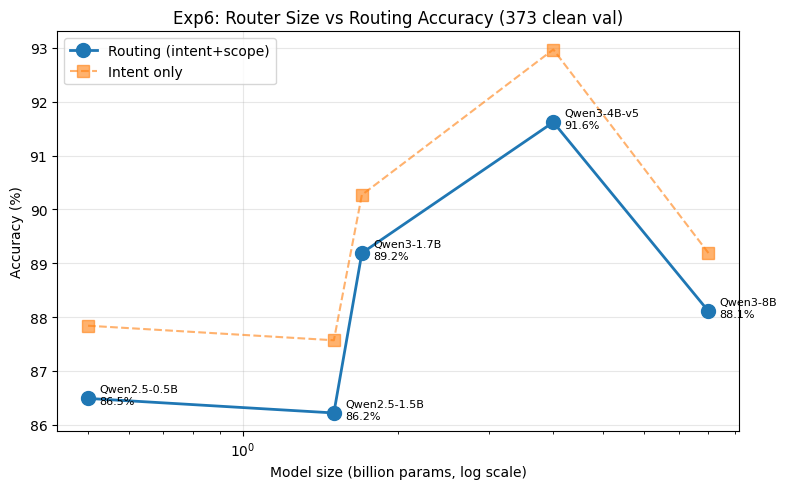

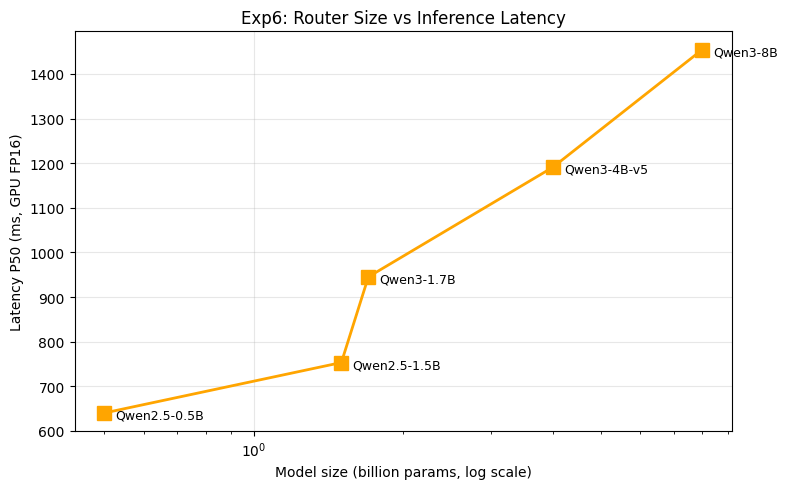

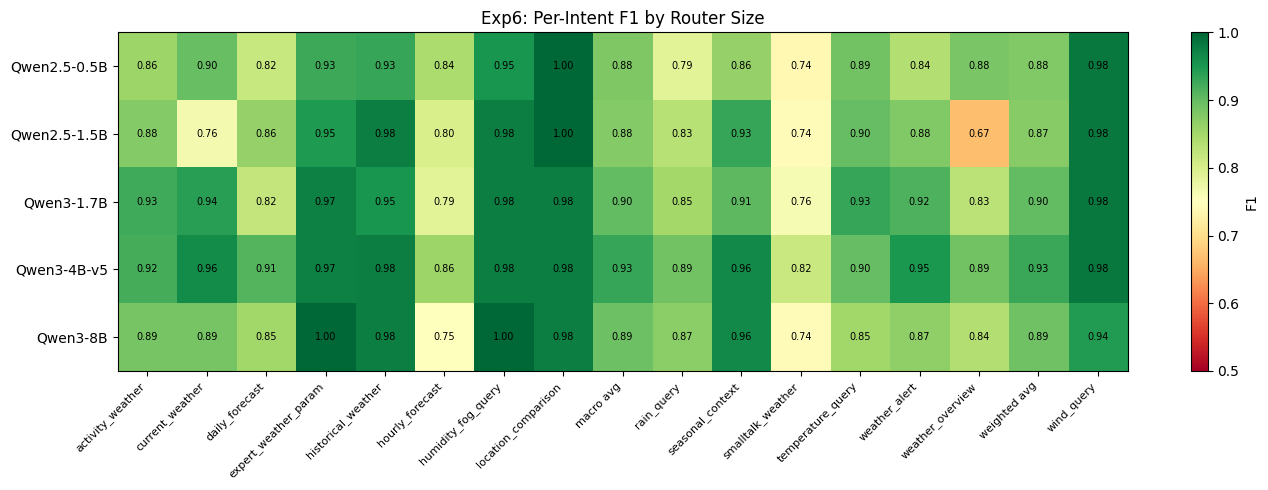


Download all files from /content/outputs/ (left panel > Files)


In [8]:
# ═══════════════════════ PLOTS ═══════════════════════
import matplotlib.pyplot as plt

sizes = [results[name]['params_billions'] for name, _, _ in MODELS]
raccs = [results[name]['routing_accuracy_pct'] for name, _, _ in MODELS]
iaccs = [results[name]['intent_accuracy_pct'] for name, _, _ in MODELS]
lats  = [results[name]['latency_p50_ms'] for name, _, _ in MODELS]
names = [name for name, _, _ in MODELS]

# Figure 1: Size vs Routing Accuracy (primary, v4-aligned)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, raccs, 'o-', linewidth=2, markersize=10, label='Routing (intent+scope)')
ax.plot(sizes, iaccs, 's--', linewidth=1.5, markersize=8, alpha=0.6, label='Intent only')
for s, a, n in zip(sizes, raccs, names):
    ax.annotate(f'{n}\n{a:.1f}%', (s, a), textcoords='offset points', xytext=(8, -4), fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Model size (billion params, log scale)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Exp6: Router Size vs Routing Accuracy (373 clean val)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp6_size_vs_accuracy.png', dpi=150)
plt.show()

# Figure 2: Size vs Latency
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, lats, 's-', color='orange', linewidth=2, markersize=10)
for s, l, n in zip(sizes, lats, names):
    ax.annotate(n, (s, l), textcoords='offset points', xytext=(8, -4), fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Model size (billion params, log scale)')
ax.set_ylabel('Latency P50 (ms, GPU FP16)')
ax.set_title('Exp6: Router Size vs Inference Latency')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp6_size_vs_latency.png', dpi=150)
plt.show()

# Figure 3: Per-intent F1 heatmap
import numpy as np
intents = sorted(results[MODELS[0][0]]['per_intent_f1'].keys())
f1_matrix = []
for name, _, _ in MODELS:
    f1_matrix.append([results[name]['per_intent_f1'].get(i, 0) for i in intents])
f1_matrix = np.array(f1_matrix)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(f1_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(intents)))
ax.set_xticklabels(intents, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(names)
for i in range(len(MODELS)):
    for j in range(len(intents)):
        ax.text(j, i, f'{f1_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='F1')
ax.set_title('Exp6: Per-Intent F1 by Router Size')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp6_per_intent_f1_heatmap.png', dpi=150)
plt.show()

print('\nDownload all files from /content/outputs/ (left panel > Files)')
